In [1]:
# Cell 1: Import necessary libraries and load the data
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path
from scipy.spatial.distance import pdist, squareform
import networkx as nx # For graph visualization
import random # For selecting random images

# Load the .mat file
# Make sure 'isomap.mat' is in a 'data' folder next to your notebook,
# or provide the full path to the file.
try:
    data = sio.loadmat('data/isomap.mat')
    # Assuming the data is stored under a key like 'images' or 'data_matrix'
    # You might need to inspect the keys of the loaded dictionary
    # by running `print(data.keys())` first to find the correct key.
    # For common .mat files from research, it's often a single main variable.
    # Let's assume the key is 'images' based on common datasets, but adjust if needed.
    # If `data.keys()` shows something like `dict_keys(['__header__', '__version__', '__globals__', 'images'])`,
    # then 'images' would be the correct key.
    
    # Let's try to find a key that looks like the main data array.
    # A simple heuristic: find the largest array.
    main_key = None
    max_dims = 0
    for key, value in data.items():
        if isinstance(value, np.ndarray) and value.size > max_dims and not key.startswith('__'):
            main_key = key
            max_dims = value.size
    
    if main_key:
        X = data[main_key]
    else:
        raise ValueError("Could not find a suitable data array in the .mat file.")

    # Check the dimensions and transpose if necessary
    # Expected: 698 rows (images), 4096 columns (pixels)
    if X.shape[0] == 4096 and X.shape[1] == 698:
        print(f"Original shape: {X.shape}. Transposing to get (698, 4096).")
        X = X.T # Transpose if it's 4096x698
    
    print(f"Loaded data shape: {X.shape}") # Should be (698, 4096)
    
except FileNotFoundError:
    print("Error: isomap.mat not found. Make sure it's in the 'data' folder or provide the correct path.")
    # Exit or handle gracefully if the file isn't found
    exit() # For a notebook, you might want to stop execution or assign dummy data.

Original shape: (4096, 698). Transposing to get (698, 4096).
Loaded data shape: (698, 4096)


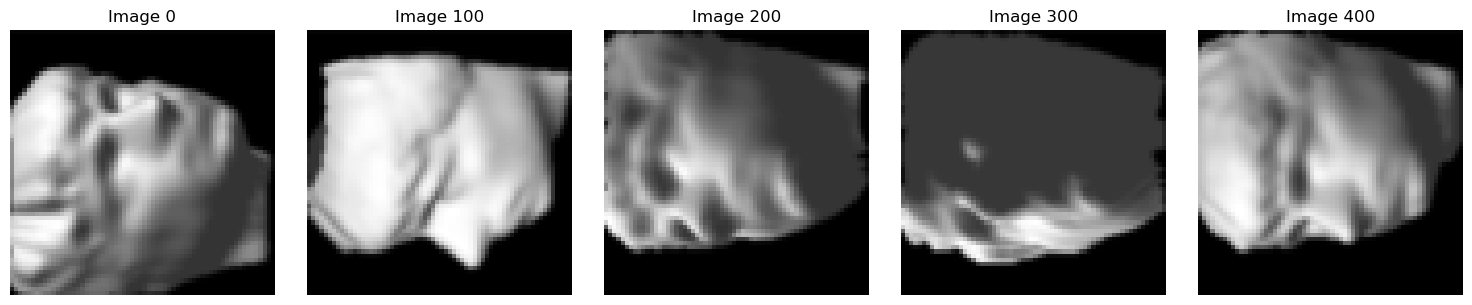

In [2]:
# Cell 2: Function to visualize a single image
def visualize_image(image_vector, ax, title=""):
    """Reshapes and displays a 4096-pixel vector as a 64x64 image."""
    image_matrix = image_vector.reshape((64, 64))
    ax.imshow(image_matrix, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

# Display a few sample images to verify
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
sample_indices = [0, 100, 200, 300, 400] # Choose some diverse indices
for i, idx in enumerate(sample_indices):
    visualize_image(X[idx], axes[i], title=f"Image {idx}")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Constructing the epsilon-ISOMAP Graph (Adjacency Matrix)
# Tuning epsilon: This is crucial. Start with a value and adjust.
# Based on diagnostics: Max Euclidean distance is ~34.69.
# Epsilon must be less than this max distance to create a sparse graph.
# Start with a value that is a small fraction of the max, or in the lower half of the range.
epsilon = 10.434941151035902 # A much more reasonable starting point. You will tune this.
                # Common range might be from ~5 to ~30 based on your D_euclidean max.

print(f"Calculating pairwise Euclidean distances for epsilon = {epsilon}...")
# Calculate all pairwise Euclidean distances
# pdist returns a condensed distance matrix, squareform converts it to a full square matrix
D_euclidean = squareform(pdist(X, metric='euclidean'))

# Create the adjacency matrix (A)
# A[i,j] = D_euclidean[i,j] if D_euclidean[i,j] <= epsilon, else infinity
# Using np.inf to represent non-edges, which is required by shortest_path
A = D_euclidean.copy()
A[A > epsilon] = np.inf

# Set diagonal to 0
np.fill_diagonal(A, 0)

print(f"Adjacency matrix constructed. Shape: {A.shape}")

Calculating pairwise Euclidean distances for epsilon = 10.434941151035902...
Adjacency matrix constructed. Shape: (698, 698)


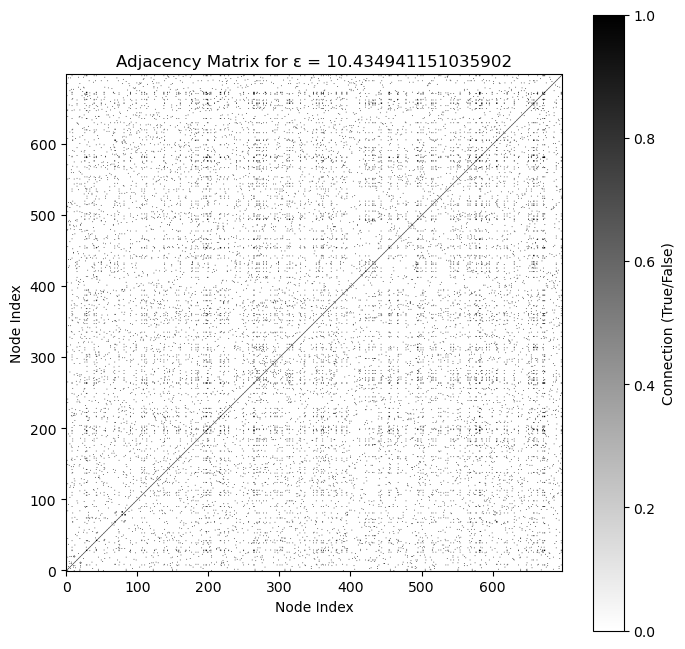

Number of connected components: 1


In [4]:
# Cell 4: Visualize the Nearest Neighbor Graph (Adjacency Matrix)
# Plotting the adjacency matrix
plt.figure(figsize=(8, 8))
plt.imshow(A != np.inf, cmap='binary', origin='lower') # Use binary colormap for clarity
plt.title(f'Adjacency Matrix for ε = {epsilon}')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.colorbar(label='Connection (True/False)')
plt.show()

# Check connectivity (optional, but good for tuning epsilon)
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
num_components, labels = connected_components(csr_matrix(A != np.inf))
print(f"Number of connected components: {num_components}")
if num_components > 1:
    print(f"Warning: Graph is disconnected with {num_components} components. Consider increasing epsilon.")

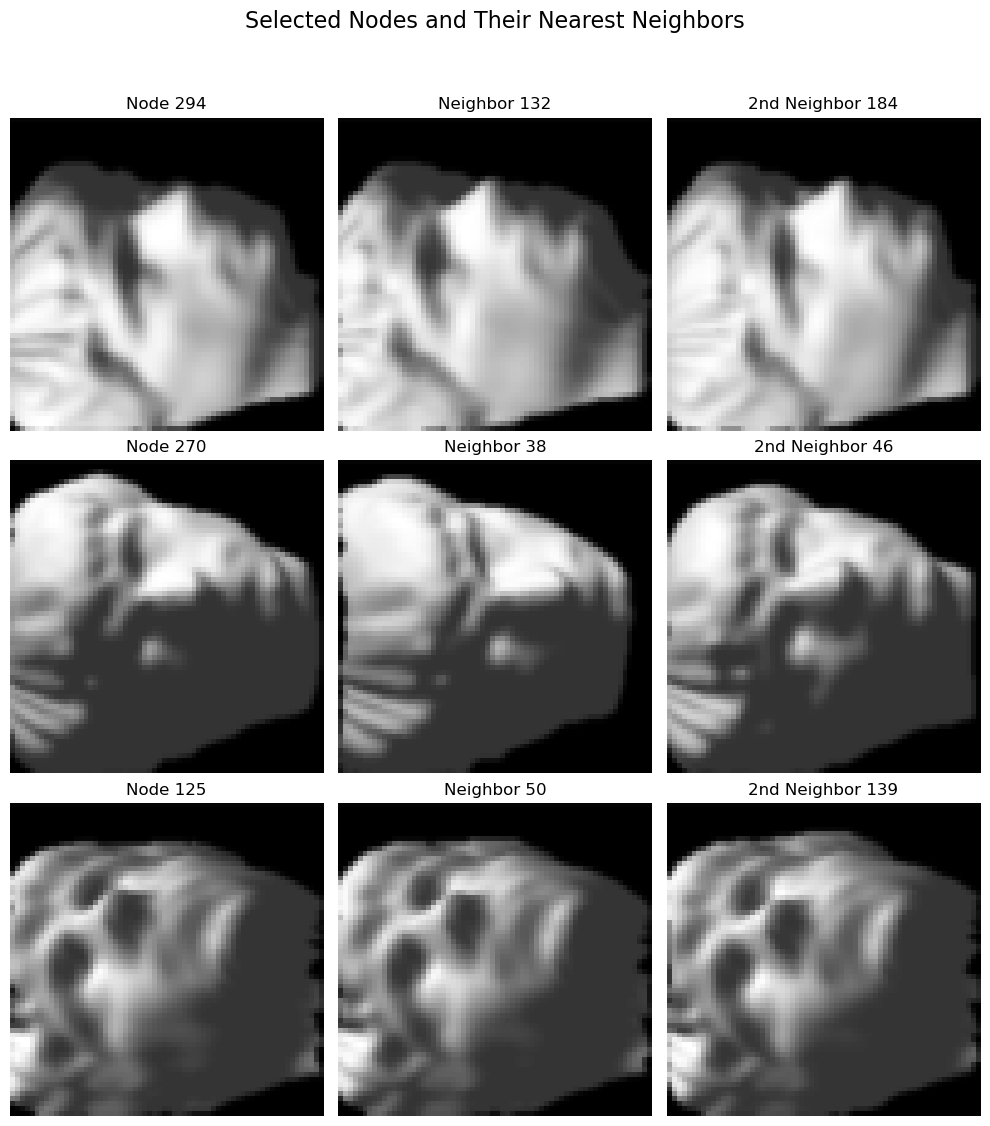

In [5]:
# Cell 5: Visualize selected face images related to the graph structure
# This is more conceptual for a 2D graph representation.
# For adjacency matrix, it's hard to pick "different parts".
# Instead, let's pick random nodes and their 1-hop neighbors (if any)
# to show how connectivity implies visual similarity.

# Select a few random nodes
num_nodes_to_show = 3
random_nodes = random.sample(range(X.shape[0]), num_nodes_to_show)

fig, axes = plt.subplots(num_nodes_to_show, 3, figsize=(10, num_nodes_to_show * 4))
fig.suptitle('Selected Nodes and Their Nearest Neighbors', fontsize=16)

for i, node_idx in enumerate(random_nodes):
    # Original node
    visualize_image(X[node_idx], axes[i, 0], title=f"Node {node_idx}")

    # Find a neighbor (if any)
    neighbors = np.where((A[node_idx, :] != np.inf) & (A[node_idx, :] != 0))[0]
    if len(neighbors) > 0:
        neighbor_idx = neighbors[0] # Just take the first one
        visualize_image(X[neighbor_idx], axes[i, 1], title=f"Neighbor {neighbor_idx}")
        # Optionally, find another neighbor if available
        if len(neighbors) > 1:
            second_neighbor_idx = neighbors[1]
            visualize_image(X[second_neighbor_idx], axes[i, 2], title=f"2nd Neighbor {second_neighbor_idx}")
        else:
            axes[i, 2].set_visible(False) # Hide empty subplot
    else:
        axes[i, 1].set_visible(False)
        axes[i, 2].set_visible(False)
        axes[i, 1].text(0.5, 0.5, "No neighbors found", ha='center', va='center', transform=axes[i, 1].transAxes)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

In [6]:
# Cell 6: Calculate all-pairs shortest paths on the graph
print("Calculating all-pairs shortest paths (Geodesic Distances)...")
# Using the precomputed adjacency matrix 'A' where non-edges are np.inf
# This computes the shortest path between all pairs of nodes using Dijkstra's or Floyd-Warshall, etc.
# Scipy automatically chooses an efficient algorithm based on sparsity.
D_geodesic = shortest_path(csgraph=A, method='auto', directed=False)

# Check for disconnected components after shortest path calculation
if np.isinf(D_geodesic).any():
    print("Warning: Some nodes are unreachable (infinity values in geodesic distances).")
    print("This means your graph is disconnected. Reconsider epsilon value.")
    # For ISOMAP to work properly, the graph must be connected.
    # You might want to filter out unreachable nodes or increase epsilon.
    # For this exercise, we will proceed, but be aware of the implications.
    # A practical approach might be to set inf to a very large number or max distance.
    # Or simply filter out nodes in disconnected components.

Calculating all-pairs shortest paths (Geodesic Distances)...


In [7]:
# Cell 7: Perform Multidimensional Scaling (MDS) on the geodesic distances
print("Performing Multidimensional Scaling (MDS)...")
from sklearn.manifold import MDS

# Initialize MDS. We want 2 components for 2D embedding.
# metric=True because we're using actual distances (geodesic distances).
# dissimilarity='precomputed' since we already have D_geodesic.
# n_init=1 ensures reproducibility; max_iter controls convergence.
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=1, max_iter=3000)

# Fit MDS to the geodesic distances to get the low-dimensional embedding
Y = mds.fit_transform(D_geodesic)

print(f"Low-dimensional embedding shape: {Y.shape}")

Performing Multidimensional Scaling (MDS)...
Low-dimensional embedding shape: (698, 2)


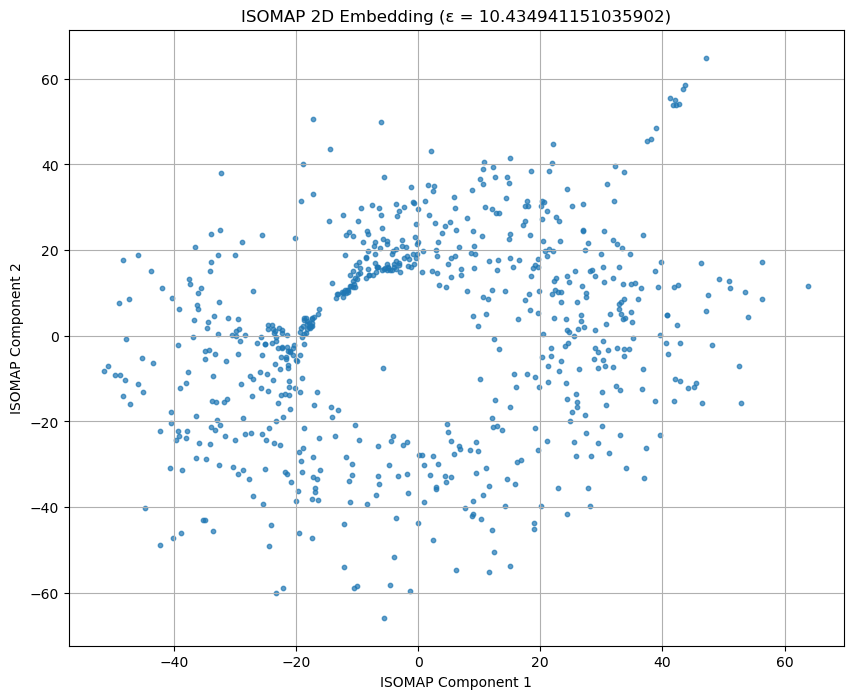

In [8]:
# Cell 8: Plot the 2D low-dimensional embedding
plt.figure(figsize=(10, 8))
plt.scatter(Y[:, 0], Y[:, 1], s=10, alpha=0.7)
plt.title(f'ISOMAP 2D Embedding (ε = {epsilon})')
plt.xlabel('ISOMAP Component 1')
plt.ylabel('ISOMAP Component 2')
plt.grid(True)
plt.show()

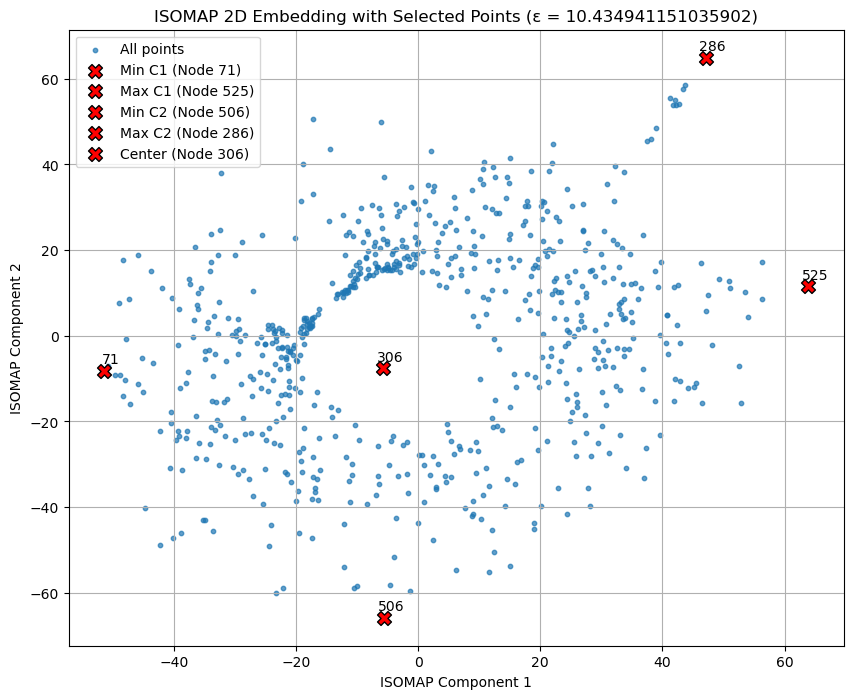

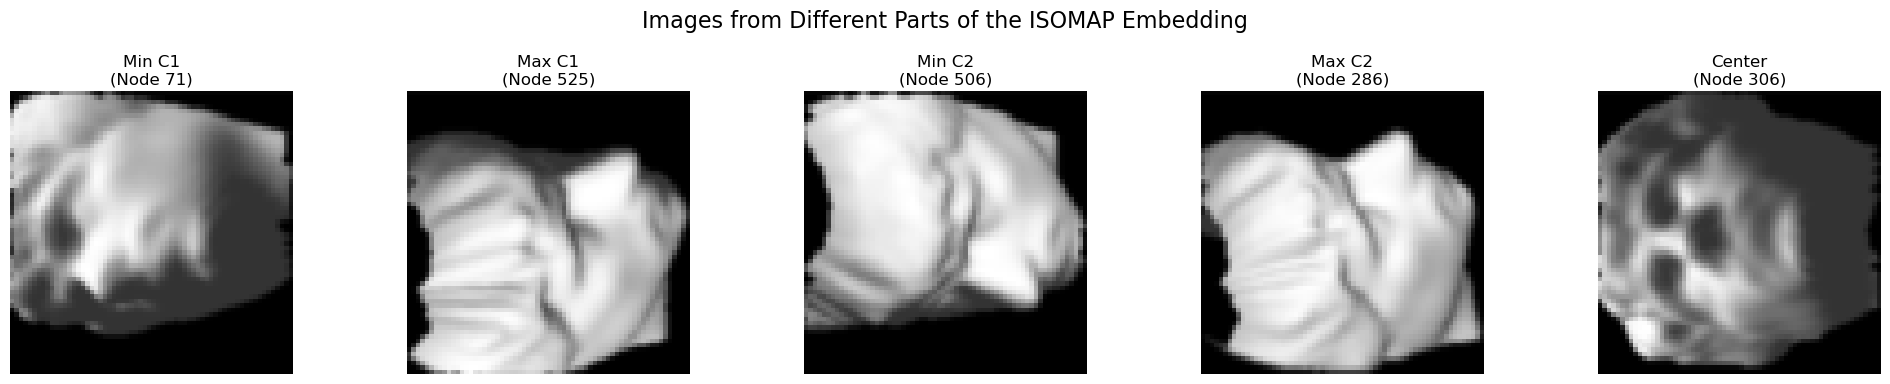


Comment on visual similarity and arrangement:
Observe the selected images. Do faces with similar poses or lighting conditions cluster together?
For instance, do images from the 'Min C1' and 'Max C1' (extremes of the first component) show a clear transition in pose or lighting?
Similarly for the second component. The goal of ISOMAP is to preserve geodesic distances, so visually similar images (small changes in pose/lighting) should be close in the embedding.


In [9]:
# Cell 9: Find and show images from different parts of the embedding space
# Select points from different regions of the scatter plot
# For example, points at extremes and center.
# We'll pick 5 points based on their coordinates.
# You can visually inspect the scatter plot and adjust these indices.

# Get indices of points close to corners/extremes
# (Min/Max of Component 1 and Component 2)
idx_min_c1 = np.argmin(Y[:, 0])
idx_max_c1 = np.argmax(Y[:, 0])
idx_min_c2 = np.argmin(Y[:, 1])
idx_max_c2 = np.argmax(Y[:, 1])

# Also, a point near the center of the embedding
center_point = np.mean(Y, axis=0)
dist_to_center = np.linalg.norm(Y - center_point, axis=1)
idx_center = np.argmin(dist_to_center)

selected_embedding_indices = [idx_min_c1, idx_max_c1, idx_min_c2, idx_max_c2, idx_center]
selected_embedding_labels = ["Min C1", "Max C1", "Min C2", "Max C2", "Center"]

# Plot the embedding again and highlight selected points
plt.figure(figsize=(10, 8))
plt.scatter(Y[:, 0], Y[:, 1], s=10, alpha=0.7, label='All points')

# Highlight selected points
for i, idx in enumerate(selected_embedding_indices):
    plt.scatter(Y[idx, 0], Y[idx, 1], s=100, color='red', marker='X', edgecolor='black', zorder=5,
                label=f'{selected_embedding_labels[i]} (Node {idx})')
    # Annotate with node index
    plt.annotate(str(idx), (Y[idx, 0], Y[idx, 1]), textcoords="offset points", xytext=(5,5), ha='center')


plt.title(f'ISOMAP 2D Embedding with Selected Points (ε = {epsilon})')
plt.xlabel('ISOMAP Component 1')
plt.ylabel('ISOMAP Component 2')
plt.grid(True)
plt.legend()
plt.show()

# Now display the actual images corresponding to these selected points
fig, axes = plt.subplots(1, len(selected_embedding_indices), figsize=(20, 4))
fig.suptitle('Images from Different Parts of the ISOMAP Embedding', fontsize=16)

for i, idx in enumerate(selected_embedding_indices):
    visualize_image(X[idx], axes[i], title=f"{selected_embedding_labels[i]}\n(Node {idx})")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nComment on visual similarity and arrangement:")
print("Observe the selected images. Do faces with similar poses or lighting conditions cluster together?")
print("For instance, do images from the 'Min C1' and 'Max C1' (extremes of the first component) show a clear transition in pose or lighting?")
print("Similarly for the second component. The goal of ISOMAP is to preserve geodesic distances, so visually similar images (small changes in pose/lighting) should be close in the embedding.")

In [10]:
# Cell 10: Implement PCA (from previous question, if applicable, or just use sklearn)
print("\nPerforming PCA for comparison...")
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA to the original high-dimensional data and transform
X_pca = pca.fit_transform(X)

print(f"PCA embedding shape: {X_pca.shape}")
print(f"Explained variance ratio by top 2 components: {pca.explained_variance_ratio_.sum():.4f}")


Performing PCA for comparison...
PCA embedding shape: (698, 2)
Explained variance ratio by top 2 components: 0.4866


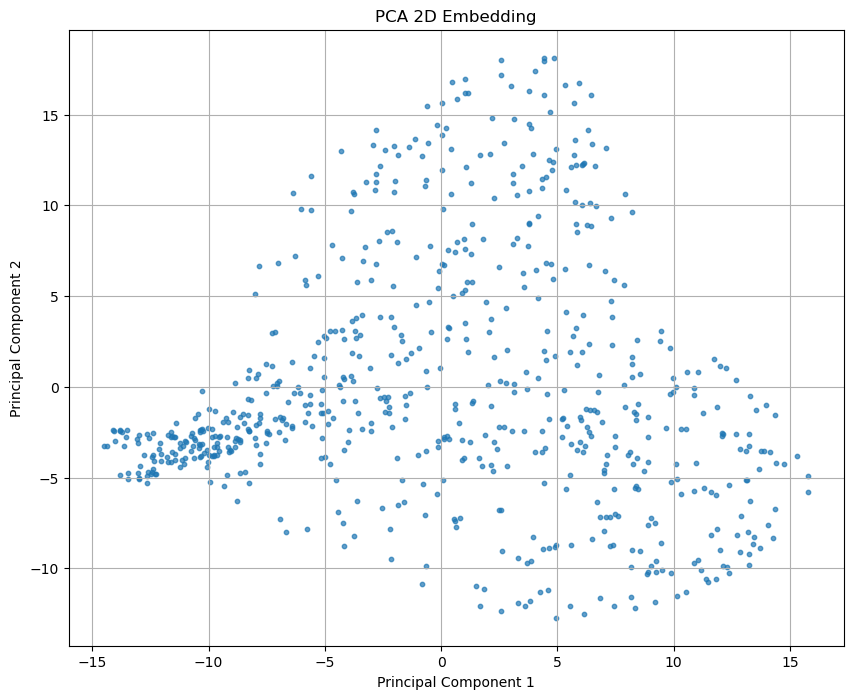

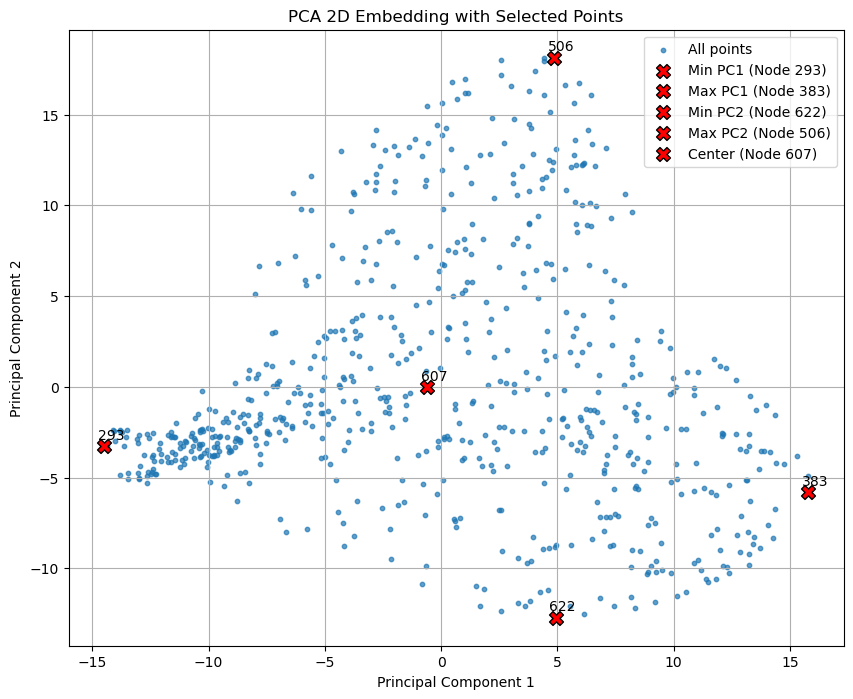

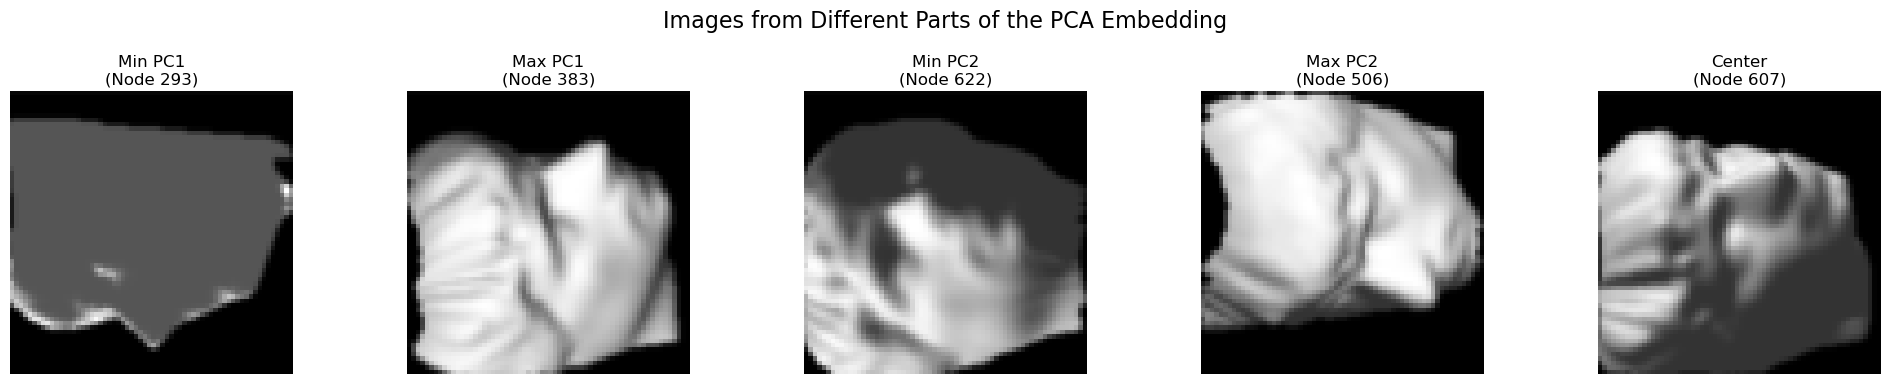

In [11]:
# Cell 11: Plot PCA 2D embedding
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.7)
plt.title('PCA 2D Embedding')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Show images corresponding to extremes in PCA space (similar to ISOMAP)
# Get indices of points close to corners/extremes in PCA
idx_pca_min_c1 = np.argmin(X_pca[:, 0])
idx_pca_max_c1 = np.argmax(X_pca[:, 0])
idx_pca_min_c2 = np.argmin(X_pca[:, 1])
idx_pca_max_c2 = np.argmax(X_pca[:, 1])

# Also, a point near the center of the embedding
center_point_pca = np.mean(X_pca, axis=0)
dist_to_center_pca = np.linalg.norm(X_pca - center_point_pca, axis=1)
idx_pca_center = np.argmin(dist_to_center_pca)

selected_pca_indices = [idx_pca_min_c1, idx_pca_max_c1, idx_pca_min_c2, idx_pca_max_c2, idx_pca_center]
selected_pca_labels = ["Min PC1", "Max PC1", "Min PC2", "Max PC2", "Center"]

# Plot the PCA embedding again and highlight selected points
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.7, label='All points')

# Highlight selected points
for i, idx in enumerate(selected_pca_indices):
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=100, color='red', marker='X', edgecolor='black', zorder=5,
                label=f'{selected_pca_labels[i]} (Node {idx})')
    # Annotate with node index
    plt.annotate(str(idx), (X_pca[idx, 0], X_pca[idx, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('PCA 2D Embedding with Selected Points')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend()
plt.show()


# Display the actual images corresponding to these selected PCA points
fig, axes = plt.subplots(1, len(selected_pca_indices), figsize=(20, 4))
fig.suptitle('Images from Different Parts of the PCA Embedding', fontsize=16)

for i, idx in enumerate(selected_pca_indices):
    visualize_image(X[idx], axes[i], title=f"{selected_pca_labels[i]}\n(Node {idx})")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()